# CXR Report Generation — Demo

In [1]:
import sys
import os
sys.path.append(os.path.dirname(os.path.abspath('')))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import h5py
import torchvision.transforms as transforms

from tokenizers import Tokenizer
from exp2_multimodal.dataset import load_and_split, CXRDataset
from model import Multimodal_Memory
from utils.config import load_config, _find_root
from utils.metrics import generate_report

/home/public/mkamal/virtual_enviroments/proj_venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
import logging

# Dummy logger

logger = logging.getLogger("dummy_logger")

logger.setLevel(logging.INFO)

if not logger.handlers:

    handler = logging.StreamHandler()

    handler.setFormatter(logging.Formatter("%(levelname)s - %(message)s"))

    logger.addHandler(handler)

# Example usage

logger.info("This is a test log message")

INFO - This is a test log message


# Config


In [17]:
CONFIG_PATH = "results_t1/best_config.yml"
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
SEED        = 42
N_SAMPLES   = 6
from utils.config import load_config, _find_root
random.seed(SEED)
torch.manual_seed(SEED)

DEFAULT = os.path.join(_find_root(), 'configs', 'multimodal_label_conf', 'main.yml')
CONFIG_PATH =  os.path.join(_find_root(), 'exp3_multimodal_swin', 'results_t1', 'best_config.yml')


print(os.path.abspath(CONFIG_PATH))

config = load_config(config_path=CONFIG_PATH, default_config=CONFIG_PATH, logger=logger)
print(f"Device: {DEVICE}")

INFO - Loading config from: /home/grad/masters/2025/mkamal/mkamal/cxr_report_gen/exp3_multimodal_swin/results_t1/best_config.yml


/home/grad/masters/2025/mkamal/mkamal/cxr_report_gen/exp3_multimodal_swin/results_t1/best_config.yml
Device: cuda


# Tokenizer

In [18]:
BASE_DIR  = os.path.abspath('')
_save_dir = config['checkpoint']['save_dir']
if not os.path.isabs(_save_dir):
    _save_dir = os.path.join(BASE_DIR, _save_dir)

tokenizer = Tokenizer.from_file(os.path.join(_save_dir, "bpe_tokenizer.json"))
word2idx  = tokenizer.get_vocab()

BOS        = config['special_tokens']['bos']
EOS        = config['special_tokens']['eos']
PAD        = config['special_tokens']['pad']
UNK        = config['special_tokens']['unk']
FINDING    = config['special_tokens']['finding']
IMPRESSION = config['special_tokens']['impression']

config['model']['vocab_size'] = tokenizer.get_vocab_size()
config['model']['pad_id']     = word2idx[PAD]

print(f"Vocab size: {tokenizer.get_vocab_size()}")

Vocab size: 16000


In [19]:
ckpt_path = os.path.join(
    config['checkpoint']['model_checkpoint_path'],
    config['checkpoint']['model_save_name']
)

ckpt  = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
model = Multimodal_Memory(**ckpt['hyperparams']).to(DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

print(f"Loaded epoch {ckpt['epoch']+1} | valid loss {ckpt['valid_loss']:.4f}")

Layer 0 frozen and set to eval().
Layer 1 frozen and set to eval().
Layer 2 frozen and set to eval().
Layer 3 frozen and set to eval().
Layer 4 frozen and set to eval().
Layer 5 frozen and set to eval().
Layer 6 frozen and set to eval().
Layer 7 frozen and set to eval().
Layer 8 frozen and set to eval().


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5419.35it/s]
BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded epoch 12 | valid loss 1.8957


# LOAD TEST SET

In [21]:
_, _, test_df = load_and_split(
    config['data']['csv_file'],
    val_size  = config['data']['valid_sz'],
    test_size = config['data']['test_sz'],
    seed      = SEED,
    logger    = logger
)

label_df = pd.read_csv(config['eval']['reports_label_path'])

test_ds = CXRDataset(
    df_reports      = test_df,
    df_labels       = label_df,
    h5_path         = config['data']['h5_file'],
    vocab           = word2idx,
    bos=BOS, eos=EOS, unk=UNK,
    finding=FINDING, impression=IMPRESSION,
    decoder_max_len = config['model']['decoder_max_len'],
    tokenizer       = tokenizer,
    transform       = transforms.Compose([
        transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ]),
)

print(f"Test set: {len(test_ds)} samples")

INFO - Dataset is being split into train-test-split (0.9, 0.1, 0.1)
INFO - Patients — train: 11230 | val: 1404 | test: 1404
INFO - Samples  — train: 67039     | val: 8464     | test: 7727


Test set: 7727 samples


# GENERATE and DISPLAY

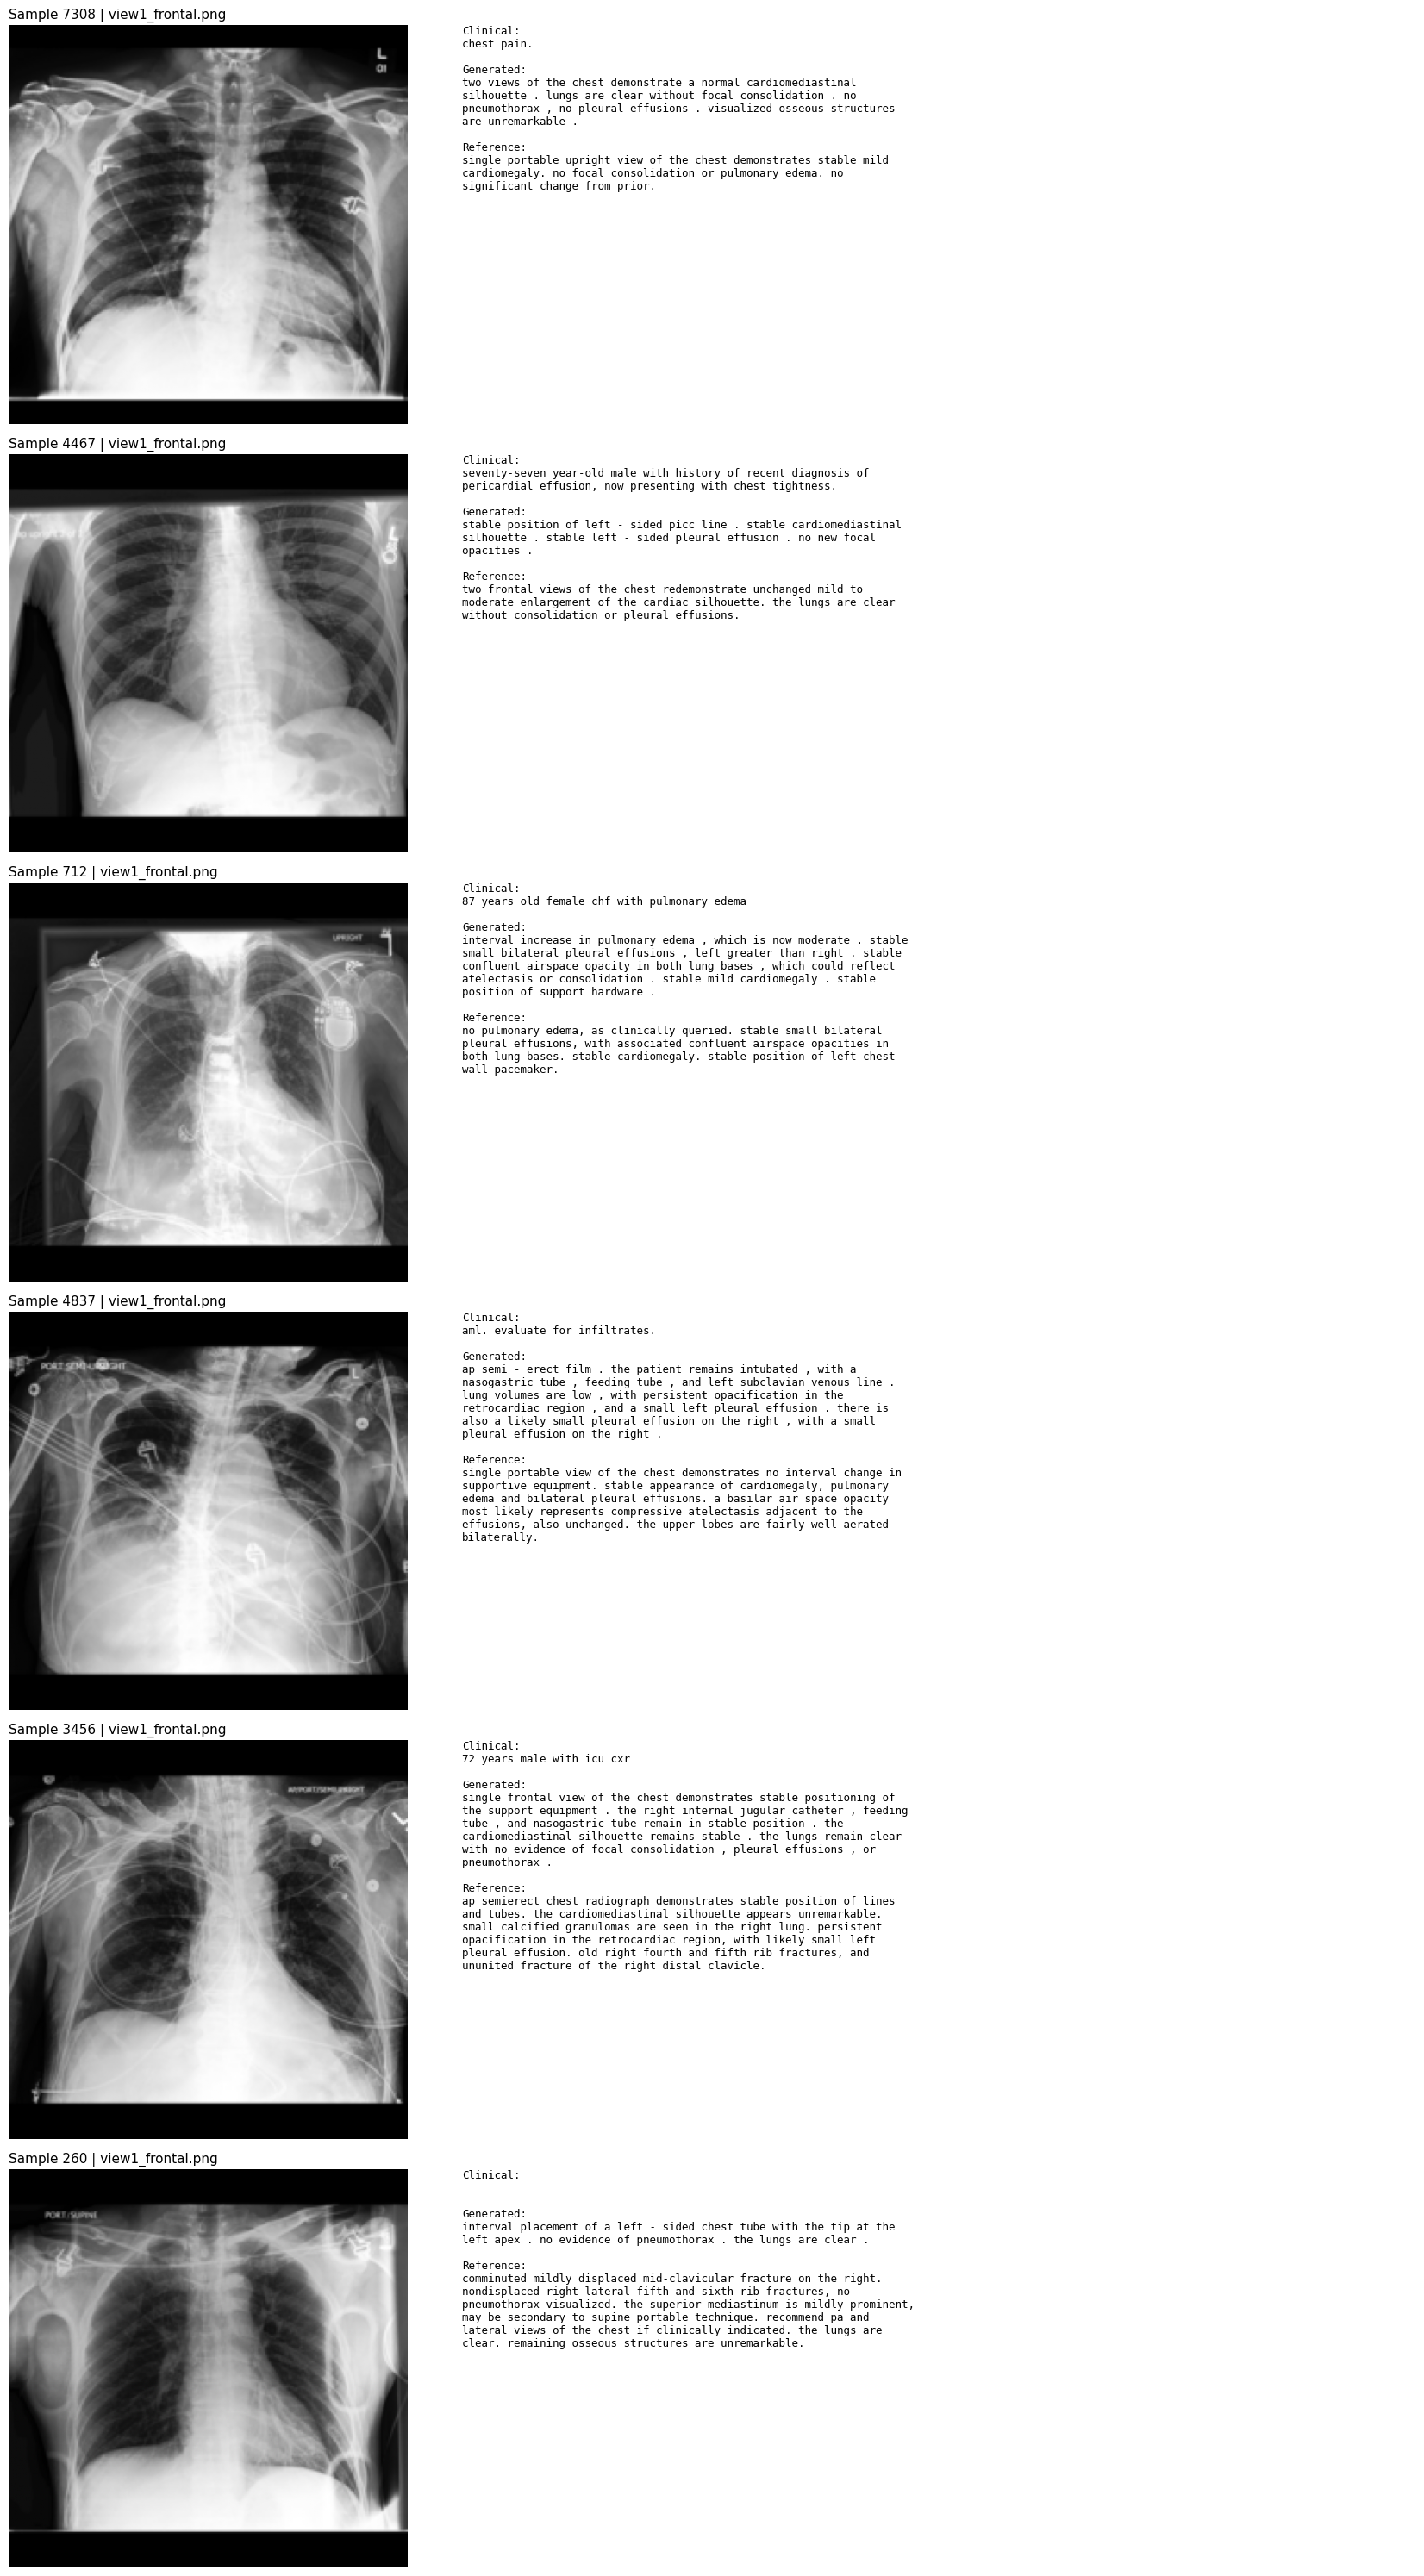

Saved → /home/grad/masters/2025/mkamal/mkamal/cxr_report_gen/exp3_multimodal_swin/results_t1/demo_outputs.png


In [26]:
import os
import random
import textwrap
import h5py
import matplotlib.pyplot as plt


def get_raw_image(h5_path, h5_idx):
    with h5py.File(h5_path, 'r') as f:
        img  = f['images'][h5_idx]           # (1, 224, 224)
        path = f['paths'][h5_idx].decode()
    return img[0], path


indices = random.sample(range(len(test_ds)), N_SAMPLES)

fig, axes = plt.subplots(
    N_SAMPLES, 2,
    figsize=(18, N_SAMPLES * 5),
    gridspec_kw={'width_ratios': [1.2, 1.8]}
)

if N_SAMPLES == 1:
    axes = [axes]

for row, idx in enumerate(indices):
    ax_img, ax_txt = axes[row] if N_SAMPLES > 1 else axes[0]

    sample   = test_ds[idx]
    h5_idx   = test_ds.indices[idx]
    ref_text = test_df.iloc[idx]['report_gen']
    clinical = sample[3]
    gen_text = generate_report(model, sample, tokenizer, word2idx, config, device=DEVICE)
    img_raw, img_path = get_raw_image(config['data']['h5_file'], h5_idx)

    # --- image ---
    ax_img.imshow(img_raw, cmap='gray')
    ax_img.axis('off')
    ax_img.set_title(
        f"Sample {idx} | {os.path.basename(img_path)}",
        fontsize=11, loc='left'
    )

    # --- text ---
    ax_txt.axis('off')
    text_block = (
        f"Clinical:\n{textwrap.fill(str(clinical), width=70)}\n\n"
        f"Generated:\n{textwrap.fill(str(gen_text), width=70)}\n\n"
        f"Reference:\n{textwrap.fill(str(ref_text), width=70)}"
    )

    ax_txt.text(
        0, 1, text_block,
        fontsize=9,
        va='top',
        ha='left',
        family='monospace',
        wrap=True
    )

plt.tight_layout()
out_path = os.path.join(_save_dir, "demo_outputs.png")
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {out_path}")

In [25]:
for i, idx in enumerate(indices):
    sample   = test_ds[idx]
    ref_text = test_df.iloc[idx]['report_gen']
    clinical = sample[3]
    gen_text = generate_report(model, sample, tokenizer, word2idx, config, device=DEVICE)

    print(f"{'='*70}")
    print(f"Sample {i+1}  (index {idx})")
    print(f"Clinical:  {clinical}")
    print(f"{'-'*70}")
    print(f"Generated: {gen_text}")
    print(f"{'-'*70}")
    print(f"Reference: {ref_text}")
    print()

Sample 1  (index 1828)
Clinical:  central line placement.
----------------------------------------------------------------------
Generated: interval placement of a right internal jugular central venous catheter with the tip in the superior vena cava . no pneumothorax . lungs are clear . cardiomediastinal silhouette is within normal limits .
----------------------------------------------------------------------
Reference: left subclavian venous line, tip in the mid superior vena cava, no evidence of pneumothorax. no evidence of acute cardiopulmonary disease.

Sample 2  (index 1143)
Clinical:  68 years old male. icu follow-up.
----------------------------------------------------------------------
Generated: portable radiograph of the chest demonstrates stable positioning of support lines and tubes . unchanged enlargement of the cardiac silhouette . unchanged small bilateral pleural effusions . unchanged mild pulmonary edema . unchanged retrocardiac opacity . otherwise no significant chan